# PSD Diagnostics — Colab Runner

Runs `analysis/run_psd_diagnostics.py` from the project mounted on Google Drive.
Two modes are provided:
- **Synthetic** — no input data required; generates a deterministic sphere-packed volume for pipeline validation.
- **Real** — supply a 3-D binary pore volume (`.npy` or `.tif`/`.tiff`, `True = pore`).

All outputs are written to `<OUTPUT_ROOT>/psd_diag_<timestamp>_<run-name>/`.

## Environment Check

In [1]:
try:
    import cupy
    cupy.zeros(1)  # trigger CUDA init
    print('GPU EDT available (CuPy detected). GPU acceleration will be used by default.')
except Exception as _e:
    print(f'CuPy not available ({_e}). CPU EDT will be used (add --no-gpu to CLI cells to silence this).')

CuPy not available (No module named 'cupy'). CPU EDT will be used (add --no-gpu to CLI cells to silence this).


## Step 3 — Configure Paths

Edit `DRIVE_PROJECT_ROOT` to match the location of the project on your Drive.

In [ ]:
import os

ANALYSIS_DIR = r'C:\Users\rony.schwartz\Documents\nnUNet4SoilXrayCT\analysis'
OUTPUT_ROOT  = r'C:\Users\rony.schwartz\Documents\psd_resources\outputs'

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print(f'ANALYSIS_DIR : {ANALYSIS_DIR}')
print(f'OUTPUT_ROOT  : {OUTPUT_ROOT}')
print('analysis/ contents:', os.listdir(ANALYSIS_DIR))

ANALYSIS_DIR : /content/drive/MyDrive/soil_microCT_images/drive_scripts/analysis
OUTPUT_ROOT  : /content/drive/MyDrive/soil_microCT_images/drive_scripts/analysis/outputs
analysis/ contents: ['colab_psd_diagnostics.ipynb', '__pycache__', 'plan.md', 'implementation_contract.md', 'psd_diagnostics_core.py', 'run_psd_diagnostics.py', '.github', 'outputs']


## Step 4 — Real Mode (binary pore volume)

Supply the path to a 3-D binary pore volume (`.npy` or `.tif`/`.tiff`; `True = pore`)
and set the physical voxel spacing in micrometres `(dz, dy, dx)`.

Edit `INPUT_VOLUME` and `VOXEL_SPACING_UM` before running.

In [ ]:
# --- EDIT THESE ---
INPUT_VOLUME     = r'C:\Users\rony.schwartz\Documents\psd_resources\bnei_reem_2_otsu.npy'
VOXEL_SPACING_UM = '15.0 15.0 15.0'   # dz dy dx  (micrometres) — verify against scan metadata
RUN_NAME         = 'scan_001'
# ------------------

print(f'Input volume : {INPUT_VOLUME}')
print(f'Voxel spacing: {VOXEL_SPACING_UM} um')

Input volume : /content/drive/MyDrive/soil_microCT_images/nnUNet_resources/bnei_reem/images/nlm_volume.npy
Voxel spacing: 15.0 15.0 15.0 um


## Step 5a — Crop Sub-Volume (optional)

Loads the full volume and saves a `(650 × 650 × 100)` sub-crop as a temporary `.npy` file.
Run this cell **before** Step 5 or Step 6 to analyse only a slice of the volume.
Adjust `CROP_Z_START` to slide the 100-slice window along the Z axis.


In [ ]:
import numpy as np, pathlib, tifffile

# --- EDIT THIS to slide the window along Z ---
CROP_Z_START = 0          # first Z slice to include (0-indexed)
# ---------------------------------------------

CROP_SHAPE = (100, 650, 650)   # (Z, Y, X) — do not change
CROP_Z_END = CROP_Z_START + CROP_SHAPE[0]

src = pathlib.Path(INPUT_VOLUME)
print(f'Loading {src} ...')

if src.suffix.lower() == '.npy':
    vol = np.load(str(src))
elif src.suffix.lower() in ('.tif', '.tiff'):
    vol = tifffile.imread(str(src))
else:
    raise ValueError(f'Unsupported format: {src.suffix}')

print(f'Full volume shape : {vol.shape}')
assert vol.ndim == 3, 'Expected a 3-D volume'
assert vol.shape[0] >= CROP_Z_END, (
    f'Z axis ({vol.shape[0]}) is smaller than CROP_Z_START + 100 = {CROP_Z_END}'
)

crop = vol[CROP_Z_START:CROP_Z_END, :CROP_SHAPE[1], :CROP_SHAPE[2]]
print(f'Cropped shape     : {crop.shape}')

crop_path = str(src.parent / f'{src.stem}_crop_z{CROP_Z_START}_{CROP_Z_END}.npy')
np.save(crop_path, crop)
print(f'Saved crop to     : {crop_path}')

# Override INPUT_VOLUME so that Steps 5 / 6 use the cropped file
INPUT_VOLUME = crop_path
print(f'INPUT_VOLUME is now set to the cropped file.')


Loading /content/drive/MyDrive/soil_microCT_images/nnUNet_resources/bnei_reem/images/nlm_volume.npy ...
Full volume shape : (652, 650, 650)
Cropped shape     : (100, 650, 650)
Saved crop to     : /content/drive/MyDrive/soil_microCT_images/nnUNet_resources/bnei_reem/images/nlm_volume_crop_z0_100.npy
INPUT_VOLUME is now set to the cropped file.


In [ ]:
!cd "{ANALYSIS_DIR}" && python run_psd_diagnostics.py real \
    --input "{INPUT_VOLUME}" \
    --voxel-spacing {VOXEL_SPACING_UM} \
    --output-root "{OUTPUT_ROOT}" \
    --run-name "{RUN_NAME}"
# Output folder: <OUTPUT_ROOT>/psd_diag_<timestamp>_<RUN_NAME>/
# Artifacts: config.json, result_psd.json, diagnostics.json, summary.json, psd_table.csv

/content/drive/MyDrive/soil_microCT_images/drive_scripts/analysis/run_psd_diagnostics.py:250: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%dT%H%M%S")
PSD Pipeline Execution
Volume shape: (100, 650, 650)
Voxel spacing (physical): (15.0, 15.0, 15.0) um
Porosity: 0.2246
GPU: True, Chunking: False

[1/3] Computing Euclidean Distance Transform...
  EDT complete. Max distance: 70.58 voxels

[Diagnostics] EDT map
  Range: 0.0000 - 70.5762
  Unique values: 4039, integer-like: False
  Histogram bins: 64, counts head [34269367, 1348082, 1406623], tail [1014, 391, 72]

[2/3] Computing Opening Map (Morphological Reconstruction)...
  Computing Opening Map (GPU Iterative, Max Radius: 70)...
    Progress: 10/70 radii processed


## Step 6 — Real Mode with Chunking (large volumes)

Use `--use-chunking` for volumes that do not fit in GPU memory.
Adjust `--chunk-size` and `--halo-width` as needed.

In [ ]:
!cd "{ANALYSIS_DIR}" && python run_psd_diagnostics.py real \
    --input "{INPUT_VOLUME}" \
    --voxel-spacing {VOXEL_SPACING_UM} \
    --output-root "{OUTPUT_ROOT}" \
    --run-name "{RUN_NAME}_chunked" \
    --use-chunking \
    --chunk-size 128 128 128 \
    --halo-width 50
# Output folder: <OUTPUT_ROOT>/psd_diag_<timestamp>_<RUN_NAME>_chunked/

## Step 7 — Inspect Outputs

List the latest run folder and print its `summary.json`.

In [ ]:
import json, pathlib

run_folders = sorted(pathlib.Path(OUTPUT_ROOT).glob('psd_diag_*'))
if not run_folders:
    print('No run folders found in', OUTPUT_ROOT)
else:
    latest = run_folders[-1]
    print(f'Latest run: {latest.name}')
    print('Files:', [f.name for f in sorted(latest.iterdir())])
    summary_path = latest / 'summary.json'
    if summary_path.exists():
        with open(summary_path) as fh:
            print(json.dumps(json.load(fh), indent=2))

## Step 8 — PSD Graph

Plots Cumulative Porosity (left axis) and Differential PSD (right axis) vs. pore diameter (µm).
Reliable data points are drawn with solid lines; unreliable points with dashed lines.

Reading: /content/drive/MyDrive/soil_microCT_images/drive_scripts/analysis/outputs/psd_diag_20260419T101941_scan_001/psd_table.csv


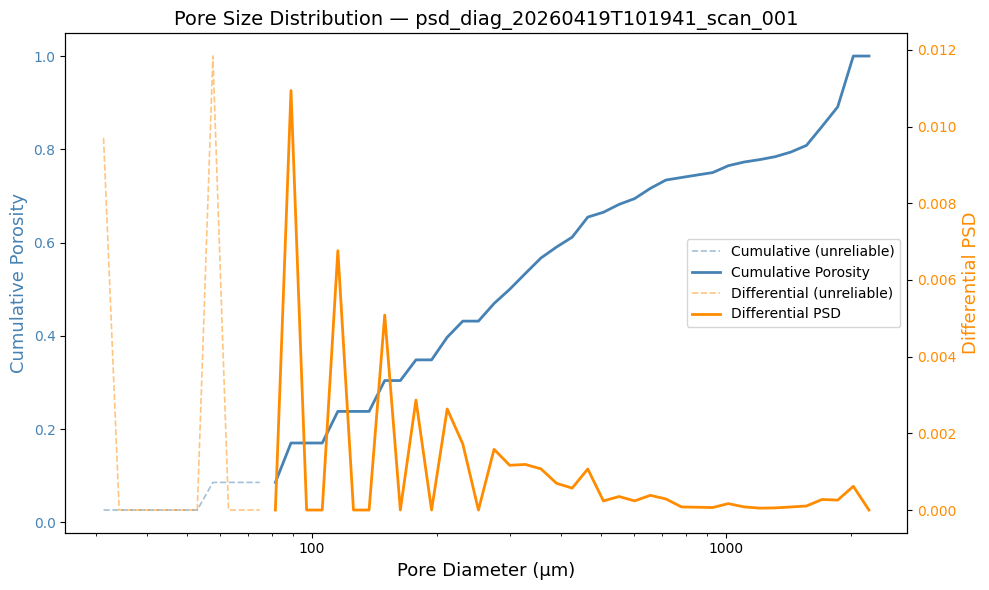

In [19]:
import json, pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Locate the latest run folder
run_folders = sorted(pathlib.Path(OUTPUT_ROOT).glob('psd_diag_*'))
if not run_folders:
    raise FileNotFoundError(f'No run folders found in {OUTPUT_ROOT}')
latest = run_folders[-1]
csv_path = latest / 'psd_table.csv'
print(f'Reading: {csv_path}')

df = pd.read_csv(csv_path)

rel  = df[df['is_reliable'] == True]
unrel = df[df['is_reliable'] == False]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# --- Cumulative Porosity (left axis) ---
if not unrel.empty:
    ax1.plot(unrel['Diameter_um'], unrel['Cumulative_Porosity'],
             color='steelblue', linestyle='--', linewidth=1.2, alpha=0.5,
             label='Cumulative (unreliable)')
ax1.plot(rel['Diameter_um'], rel['Cumulative_Porosity'],
         color='steelblue', linestyle='-', linewidth=2,
         label='Cumulative Porosity')

# --- Differential PSD (right axis) ---
if not unrel.empty:
    ax2.plot(unrel['Diameter_um'], unrel['Differential_PSD'],
             color='darkorange', linestyle='--', linewidth=1.2, alpha=0.5,
             label='Differential (unreliable)')
ax2.plot(rel['Diameter_um'], rel['Differential_PSD'],
         color='darkorange', linestyle='-', linewidth=2,
         label='Differential PSD')

ax1.set_xscale('log')
ax1.set_xlabel('Pore Diameter (µm)', fontsize=13)
ax1.set_ylabel('Cumulative Porosity', color='steelblue', fontsize=13)
ax2.set_ylabel('Differential PSD', color='darkorange', fontsize=13)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(ticker.NullFormatter())

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center right', fontsize=10)

plt.title(f'Pore Size Distribution — {latest.name}', fontsize=14)
plt.tight_layout()
plt.show()
